# Market Efficiency in College Football Betting
### JEM207 - Data Processing in Python
this notebook pulls CFB betting data, cleans it up and does some basic analysis

In [1]:
# install what we need
%pip install requests pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# paste key here
API_KEY = "U2eGkgwfQkOeH2/mocpZ0EB4UXA759iQjun9G3AWTTbAwB+nx2pssfQyzMLtE71A"

HEADERS = {"Authorization": f"Bearer {API_KEY}"}
BASE_URL = "https://api.collegefootballdata.com"

## 1. Data Collection
pulling game results and betting lines from the API for a few seasons

In [3]:
# gonna pull a few seasons worth of data
seasons = [2020, 2021, 2022, 2023]

all_lines = []

for year in seasons:
    response = requests.get(
        f"{BASE_URL}/lines",
        headers=HEADERS,
        params={"year": year, "seasonType": "regular"}
    )
    
    if response.status_code == 200:
        data = response.json()
        all_lines.extend(data)
        print(f"{year}: got {len(data)} games")
    else:
        print(f"{year}: something went wrong, status {response.status_code}")

print(f"\ntotal games collected: {len(all_lines)}")

2020: got 542 games
2021: got 849 games
2022: got 1417 games
2023: got 1350 games

total games collected: 4158


## 2. Cleaning
flatten everything into a dataframe and drop the stuff we dont need

In [4]:
rows = []

for game in all_lines:
    for line in game.get("lines", []):
        # only keep consensus lines, other providers have weird data
        if line.get("provider") != "consensus":
            continue
        rows.append({
            "season": game["season"],
            "week": game["week"],
            "home_team": game["homeTeam"],
            "away_team": game["awayTeam"],
            "home_score": game["homeScore"],
            "away_score": game["awayScore"],
            "spread": line.get("spread"),
            "over_under": line.get("overUnder"),
            "home_moneyline": line.get("homeMoneyline"),
            "away_moneyline": line.get("awayMoneyline"),
        })

df = pd.DataFrame(rows)
print(f"dataframe shape: {df.shape}")
df.head()

dataframe shape: (2603, 10)


,season,week,home_team,away_team,home_score,away_score,spread,over_under,home_moneyline,away_moneyline
0,2020,11,Florida,Arkansas,63,35,-17.0,62.0,None,None
1,2020,12,Air Force,New Mexico,28,0,-8.0,55.5,None,None
2,2020,12,Alabama,Kentucky,63,3,-31.5,57.5,None,None
3,2020,12,Ohio State,Indiana,42,35,-21.0,67.5,None,None
4,2020,12,Arkansas,LSU,24,27,1.5,65.0,None,None


In [5]:
# convert to numbers, some values come in as strings for some reason
df["spread"] = pd.to_numeric(df["spread"], errors="coerce")
df["over_under"] = pd.to_numeric(df["over_under"], errors="coerce")
df["home_score"] = pd.to_numeric(df["home_score"], errors="coerce")
df["away_score"] = pd.to_numeric(df["away_score"], errors="coerce")

# drop rows where we dont have scores or spread
df = df.dropna(subset=["spread", "home_score", "away_score"])

print(f"clean dataframe: {df.shape}")
print(f"\nmissing values:")
print(df.isnull().sum())

clean dataframe: (2603, 10)

missing values:
season               0
week                 0
home_team            0
away_team            0
home_score           0
away_score           0
spread               0
over_under           0
home_moneyline    2603
away_moneyline    2603
dtype: int64


In [6]:
# add some useful columns
df["actual_margin"] = df["home_score"] - df["away_score"]
df["total_points"] = df["home_score"] + df["away_score"]

# did the home team cover? (negative spread means home is favored)
df["home_covered"] = df["actual_margin"] > df["spread"]

# did the over hit?
df["over_hit"] = df["total_points"] > df["over_under"]

df.head()

,season,week,home_team,away_team,home_score,away_score,spread,over_under,home_moneyline,away_moneyline,actual_margin,total_points,home_covered,over_hit
0,2020,11,Florida,Arkansas,63,35,-17.0,62.0,None,None,28,98,True,True
1,2020,12,Air Force,New Mexico,28,0,-8.0,55.5,None,None,28,28,True,False
2,2020,12,Alabama,Kentucky,63,3,-31.5,57.5,None,None,60,66,True,True
3,2020,12,Ohio State,Indiana,42,35,-21.0,67.5,None,None,7,77,True,True
4,2020,12,Arkansas,LSU,24,27,1.5,65.0,None,None,-3,51,False,False


## 3. Basic Analysis

In [7]:
# how often do favorites cover?
cover_rate = df["home_covered"].mean() * 100
over_rate = df["over_hit"].mean() * 100

print(f"Home team cover rate: {cover_rate:.1f}%")
print(f"Over hit rate: {over_rate:.1f}%")
print(f"Total games analyzed: {len(df)}")

Home team cover rate: 62.2%
Over hit rate: 48.9%
Total games analyzed: 2603


In [8]:
# cover rate by season
print("Cover rate by season:")
print(df.groupby("season")["home_covered"].mean().apply(lambda x: f"{x*100:.1f}%"))

Cover rate by season:
season
2020    61.6%
2021    61.3%
2022    62.7%
2023    79.3%
Name: home_covered, dtype: object


In [9]:
# average spread vs average actual margin
print(f"Average spread: {df['spread'].mean():.2f}")
print(f"Average actual margin: {df['actual_margin'].mean():.2f}")
# if these are close the market is doing a good job

Average spread: -6.13
Average actual margin: 5.69


## 4. Quick Plots
just some basic charts to see whats going on

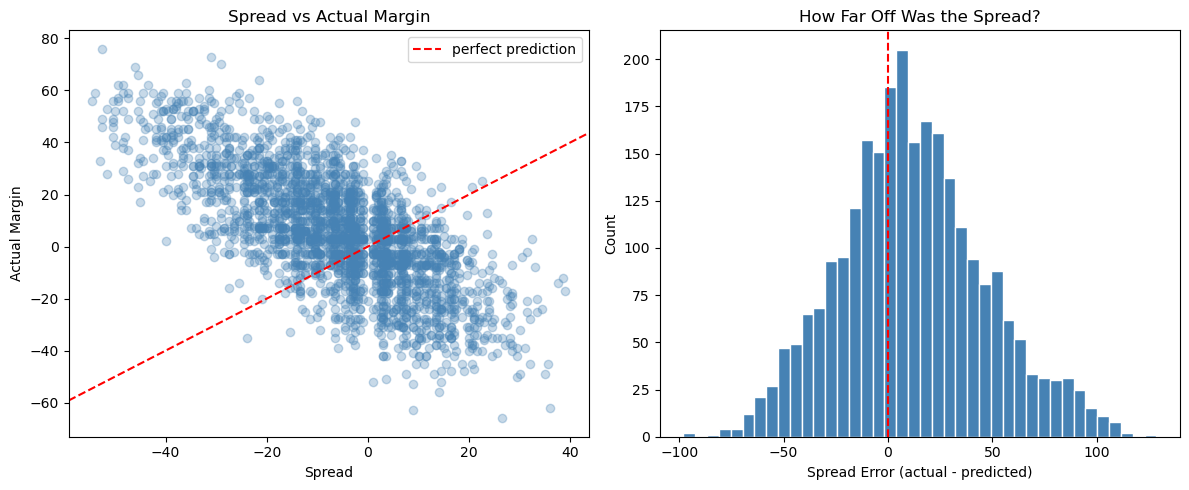

saved chart!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# spread vs actual margin scatter
axes[0].scatter(df["spread"], df["actual_margin"], alpha=0.3, color="steelblue")
axes[0].axline((0, 0), slope=1, color="red", linestyle="--", label="perfect prediction")
axes[0].set_xlabel("Spread")
axes[0].set_ylabel("Actual Margin")
axes[0].set_title("Spread vs Actual Margin")
axes[0].legend()

# distribution of how wrong the spread was
df["spread_error"] = df["actual_margin"] - df["spread"]
axes[1].hist(df["spread_error"], bins=40, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Spread Error (actual - predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title("How Far Off Was the Spread?")

plt.tight_layout()
plt.savefig("cfb_analysis.png", dpi=150)
plt.show()
print("saved chart!")

In [11]:
# save the clean data so partner can use it for their visualizations
df.to_csv("cfb_cleaned_data.csv", index=False)
print(f"saved cfb_cleaned_data.csv with {len(df)} rows")
print("done! sending this to my partner now")

saved cfb_cleaned_data.csv with 2603 rows
done! sending this to my partner now
